# Clasificación — Predicción de Dirección del Oro

**Autor**: Juan (Scrum Master)

**Objetivo**: Predecir si el oro sube o baja al día siguiente usando variables de precio e indicadores macro.

**Dataset**: GC=F (oro) + DXY (dólar) + VIX (volatilidad) + TNX (bono 10Y) desde 2015.
Datos descargados por Joel mediante `src/extract/extract.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost no instalado. Se omitirá.')

sns.set_style('whitegrid')
%matplotlib inline

## 1. Carga de datos

Cargamos el CSV generado por Joel. Contiene Open, High, Low, Close, Volume para cada uno de los 4 activos.

**Por qué estos tickers**:
- GC=F: precio del oro (nuestro target)
- DXY: índice del dólar. El oro se mueve inversamente al dólar
- VIX: índice de miedo. En crisis el oro sube como activo refugio
- TNX: bono USA a 10 años. Tipos altos → oro menos atractivo

In [2]:
DATA_PATH = '../data/raw/gold-macro-data.csv'
df = pd.read_csv(DATA_PATH, index_col="Date", parse_dates=True)

print(f'Registros: {len(df)}')
print(f'Rango: {df.index[0].date()} a {df.index[-1].date()}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Registros: 2894
Rango: 2015-01-02 a 2026-06-30
Columnas: ["Gold_('Close', 'GC=F')", "Gold_('High', 'GC=F')", "Gold_('Low', 'GC=F')", "Gold_('Open', 'GC=F')", "Gold_('Volume', 'GC=F')", "DXY_('Close', 'DX-Y.NYB')", "DXY_('High', 'DX-Y.NYB')", "DXY_('Low', 'DX-Y.NYB')", "DXY_('Open', 'DX-Y.NYB')", "DXY_('Volume', 'DX-Y.NYB')", "VIX_('Close', '^VIX')", "VIX_('High', '^VIX')", "VIX_('Low', '^VIX')", "VIX_('Open', '^VIX')", "VIX_('Volume', '^VIX')", "TNX_('Close', '^TNX')", "TNX_('High', '^TNX')", "TNX_('Low', '^TNX')", "TNX_('Open', '^TNX')", "TNX_('Volume', '^TNX')"]


,"Gold_('Close', 'GC=F')","Gold_('High', 'GC=F')","Gold_('Low', 'GC=F')","Gold_('Open', 'GC=F')","Gold_('Volume', 'GC=F')","DXY_('Close', 'DX-Y.NYB')","DXY_('High', 'DX-Y.NYB')","DXY_('Low', 'DX-Y.NYB')","DXY_('Open', 'DX-Y.NYB')","DXY_('Volume', 'DX-Y.NYB')","VIX_('Close', '^VIX')","VIX_('High', '^VIX')","VIX_('Low', '^VIX')","VIX_('Open', '^VIX')","VIX_('Volume', '^VIX')","TNX_('Close', '^TNX')","TNX_('High', '^TNX')","TNX_('Low', '^TNX')","TNX_('Open', '^TNX')","TNX_('Volume', '^TNX')"
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138.0,91.080002,91.160004,90.330002,90.360001,0.0,17.790001,20.139999,17.049999,17.760000,0.0,2.123,2.213,2.102,2.197,0.0
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470.0,91.379997,91.779999,91.129997,91.129997,0.0,19.920000,21.290001,19.190001,19.190001,0.0,2.039,2.109,2.037,2.102,0.0
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97.0,91.500000,91.809998,91.120003,91.379997,0.0,21.120001,22.900000,19.520000,20.330000,0.0,1.963,1.997,1.889,1.968,0.0
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29.0,91.889999,92.269997,91.650002,91.750000,0.0,19.309999,20.719999,19.040001,20.150000,0.0,1.954,2.008,1.938,1.975,0.0
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92.0,92.370003,92.529999,91.940002,91.940002,0.0,17.010000,18.090000,16.990000,17.930000,0.0,2.016,2.030,1.988,2.004,0.0


In [3]:
df.describe()

,"Gold_('Close', 'GC=F')","Gold_('High', 'GC=F')","Gold_('Low', 'GC=F')","Gold_('Open', 'GC=F')","Gold_('Volume', 'GC=F')","DXY_('Close', 'DX-Y.NYB')","DXY_('High', 'DX-Y.NYB')","DXY_('Low', 'DX-Y.NYB')","DXY_('Open', 'DX-Y.NYB')","DXY_('Volume', 'DX-Y.NYB')","VIX_('Close', '^VIX')","VIX_('High', '^VIX')","VIX_('Low', '^VIX')","VIX_('Open', '^VIX')","VIX_('Volume', '^VIX')","TNX_('Close', '^TNX')","TNX_('High', '^TNX')","TNX_('Low', '^TNX')","TNX_('Open', '^TNX')","TNX_('Volume', '^TNX')"
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2890.000000,2890.000000,2890.000000,2890.000000,2.890000e+03,2890.000000,2890.000000,2890.000000,2890.000000,2890.0,2886.000000,2886.000000,2886.000000,2886.000000,2886.0
mean,1895.675552,1906.066552,1885.063816,1895.607342,5099.287396,98.339460,98.644381,98.023980,98.328271,8.058824e+03,18.377225,19.651176,17.515104,18.545858,0.0,2.711129,2.738598,2.682491,2.710012,0.0
std,880.609134,889.446785,871.866307,881.357986,27813.834284,4.769948,4.808121,4.723328,4.769941,3.140951e+05,7.018789,7.889364,6.324863,7.083135,0.0,1.159310,1.163060,1.155591,1.159226,0.0
min,1050.800049,1062.000000,1046.199951,1053.699951,0.000000,88.589996,89.000000,88.250000,88.570000,0.000000e+00,9.140000,9.310000,8.560000,9.010000,0.0,0.499000,0.538000,0.398000,0.484000,0.0
25%,1275.574982,1280.800049,1271.574982,1276.574982,53.750000,94.932501,95.269997,94.629997,94.932501,0.000000e+00,13.662500,14.360000,13.260000,13.850000,0.0,1.786500,1.816250,1.766000,1.792250,0.0
50%,1730.299988,1741.000000,1722.000000,1731.450012,211.000000,97.715000,97.989998,97.440002,97.720001,0.000000e+00,16.695001,17.700001,16.070000,16.850000,0.0,2.452500,2.480500,2.425000,2.453000,0.0
75%,1975.325012,1981.224976,1963.700012,1973.724976,652.000000,101.584997,101.907503,101.217501,101.580002,0.000000e+00,21.197501,22.807499,20.180000,21.540001,0.0,3.915000,3.959750,3.869750,3.903750,0.0
max,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000,114.110001,114.779999,113.330002,114.190002,1.429000e+07,82.690002,85.470001,70.370003,82.690002,0.0,4.988000,4.997000,4.894000,4.997000,0.0


### 1.1 Limpieza de columnas

El CSV tiene nombres de columna con paréntesis y comillas. Los limpiamos y extraemos:
- **Close** de los 4 activos (gold, dxy, vix, tnx)
- **Open, High, Low** del oro para features intradiarias (body, rango)

In [4]:
df.columns = [
    col.replace("('", '_').replace("', '", '_').replace("')", '')
    for col in df.columns
]

close_cols = [c for c in df.columns if 'Close' in c]
print('Columnas de cierre:', close_cols)

macro = df[close_cols].copy()
macro.columns = ['gold', 'dxy', 'vix', 'tnx']

gold_open = df[[c for c in df.columns if 'Open_GC' in c][0]].copy()
gold_high = df[[c for c in df.columns if 'High_GC' in c][0]].copy()
gold_low  = df[[c for c in df.columns if 'Low_GC' in c][0]].copy()

gold_ohlc = pd.DataFrame({
    'gold_open': gold_open,
    'gold_high': gold_high,
    'gold_low': gold_low,
    'gold_close': macro['gold']
}, index=macro.index)

data = pd.concat([macro, gold_ohlc], axis=1)
data.dropna(inplace=True)

print(f'Registros limpios: {len(data)}')
data.head()

Columnas de cierre: ['Gold__Close_GC=F', 'DXY__Close_DX-Y.NYB', 'VIX__Close_^VIX', 'TNX__Close_^TNX']
Registros limpios: 2884


,gold,dxy,vix,tnx,gold_open,gold_high,gold_low,gold_close
Date,,,,,,,,
2015-01-02,1186.000000,91.080002,17.790001,2.123,1184.000000,1194.500000,1169.500000,1186.000000
2015-01-05,1203.900024,91.379997,19.920000,2.039,1180.300049,1206.900024,1180.099976,1203.900024
2015-01-06,1219.300049,91.500000,21.120001,1.963,1203.500000,1220.000000,1203.500000,1219.300049
2015-01-07,1210.599976,91.889999,19.309999,1.954,1219.199951,1219.199951,1210.599976,1210.599976
2015-01-08,1208.400024,92.370003,17.010000,2.016,1207.000000,1215.699951,1206.300049,1208.400024


### 1.2 Visualización rápida

Evolución de las 4 series. Se observa la relación inversa entre oro y dólar, y los picos de VIX en momentos de crisis (2020).

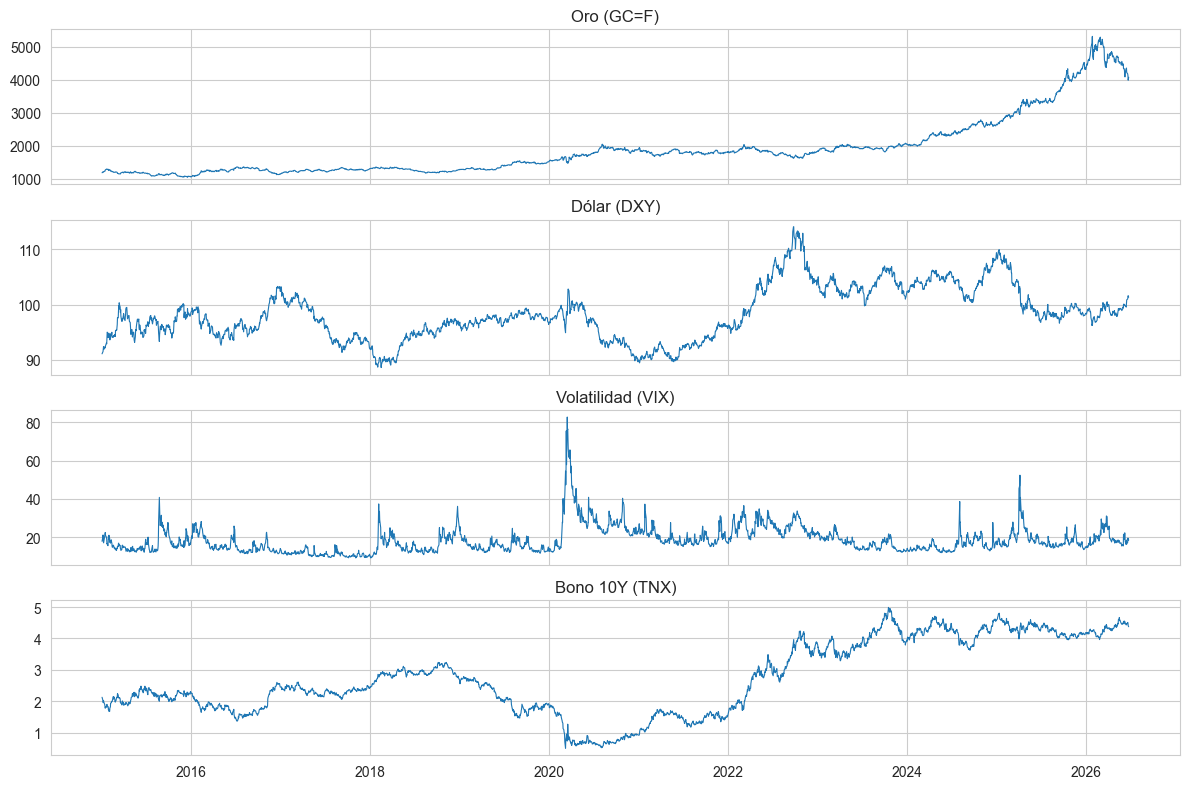

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
titles = ['Oro (GC=F)', 'Dólar (DXY)', 'Volatilidad (VIX)', 'Bono 10Y (TNX)']
for ax, col, title in zip(axes, ['gold', 'dxy', 'vix', 'tnx'], titles):
    ax.plot(data.index, data[col], linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 2. Feature engineering

Refactorizamos toda la creación de features en una función `add_features()` para facilitar la experimentación y reutilización.

**Nuevas features añadidas respecto a la versión anterior**:
- `Gold_Body_pct`: (Close - Open) / Open — indica si la sesión fue alcista o bajista
- `Gold_Range`: (High - Low) / Open — volatilidad intradiaria
- `Gold_Return_3d`, `Gold_Return_7d`: retornos multidis día
- `Gold_Close_MA20_Ratio`: distancia del precio a su media de 20 días
- `MACD_Histogram`: macd - macd_signal (señal de cruce clásica)
- MAs y volatilidades para DXY, VIX, TNX (5, 20 periodos)

In [6]:
def add_features(df):
    """Engorda el DataFrame con features técnicas y macro.
    
    Espera columnas:
      gold, dxy, vix, tnx (Close)
      gold_open, gold_high, gold_low (OHLC del oro)
    """
    d = df.copy()
    
    d['returns'] = d['gold'].pct_change()
    d['Gold_Return_3d'] = d['gold'].pct_change(3)
    d['Gold_Return_7d'] = d['gold'].pct_change(7)
    
    d['ma_5'] = d['gold'].rolling(5).mean()
    d['ma_10'] = d['gold'].rolling(10).mean()
    d['ma_21'] = d['gold'].rolling(21).mean()
    d['Gold_Close_MA20_Ratio'] = d['gold'] / d['ma_21'] - 1
    
    d['volatility_5'] = d['returns'].rolling(5).std()
    d['volatility_10'] = d['returns'].rolling(10).std()
    d['volatility_21'] = d['returns'].rolling(21).std()
    
    d['Gold_Body_pct'] = (d['gold_close'] - d['gold_open']) / d['gold_open']
    d['Gold_Range'] = (d['gold_high'] - d['gold_low']) / d['gold_open']
    
    delta = d['gold'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    d['rsi'] = 100 - (100 / (1 + rs))
    
    ema_12 = d['gold'].ewm(span=12).mean()
    ema_26 = d['gold'].ewm(span=26).mean()
    d['macd'] = ema_12 - ema_26
    d['macd_signal'] = d['macd'].ewm(span=9).mean()
    d['MACD_Histogram'] = d['macd'] - d['macd_signal']
    
    d['dxy_return'] = d['dxy'].pct_change()
    d['vix_return'] = d['vix'].pct_change()
    d['tnx_return'] = d['tnx'].pct_change()
    
    d['DXY_MA_5'] = d['dxy'].rolling(5).mean()
    d['DXY_MA_20'] = d['dxy'].rolling(20).mean()
    d['DXY_Volatility_10'] = d['dxy_return'].rolling(10).std()
    
    d['VIX_MA_5'] = d['vix'].rolling(5).mean()
    d['VIX_MA_20'] = d['vix'].rolling(20).mean()
    d['VIX_Volatility_10'] = d['vix_return'].rolling(10).std()
    
    d['TNX_MA_5'] = d['tnx'].rolling(5).mean()
    d['TNX_MA_20'] = d['tnx'].rolling(20).mean()
    d['TNX_Volatility_10'] = d['tnx_return'].rolling(10).std()
    
    d['target_bin'] = (d['gold'].shift(-1) > d['gold']).astype(int)
    fut_ret = d['gold'].pct_change(-1) * 100
    
    low_th = fut_ret.quantile(0.33)
    high_th = fut_ret.quantile(0.66)
    d['target_multi'] = np.select(
        [fut_ret < low_th, fut_ret > high_th],
        [0, 2], default=1
    )
    
    d.dropna(inplace=True)
    return d

d = add_features(data)
print(f'Filas con features: {len(d)}')
print(f'Columnas de features: {len([c for c in d.columns if c not in ["target_bin","target_multi","gold","dxy","vix","tnx","gold_open","gold_high","gold_low","gold_close"]] )}')
d.head()

Filas con features: 2863
Columnas de features: 28


,gold,dxy,vix,tnx,gold_open,gold_high,gold_low,gold_close,returns,Gold_Return_3d,...,DXY_MA_20,DXY_Volatility_10,VIX_MA_5,VIX_MA_20,VIX_Volatility_10,TNX_MA_5,TNX_MA_20,TNX_Volatility_10,target_bin,target_multi
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-03,1259.699951,93.599998,17.330000,1.780,1273.500000,1284.699951,1255.300049,1259.699951,-0.012929,0.004065,...,93.2590,0.007292,19.386,19.0720,0.109810,1.7206,1.83810,0.036875,1,1
2015-02-04,1263.800049,93.989998,18.330000,1.797,1262.000000,1271.599976,1256.800049,1263.800049,0.003255,-0.011498,...,93.3835,0.007324,18.964,18.9325,0.110434,1.7352,1.82980,0.035944,0,1
2015-02-05,1262.000000,94.699997,16.850000,1.815,1271.800049,1272.599976,1257.800049,1262.000000,-0.001424,-0.011127,...,93.5240,0.006178,18.582,18.8095,0.104824,1.7480,1.82285,0.035129,0,2
2015-02-06,1233.900024,94.699997,17.290001,1.938,1265.000000,1267.599976,1228.000000,1233.900024,-0.022266,-0.020481,...,93.6405,0.005579,17.846,18.8235,0.104965,1.8006,1.81895,0.038869,1,0
2015-02-09,1240.800049,94.449997,18.549999,1.948,1237.500000,1242.300049,1235.400024,1240.800049,0.005592,-0.018199,...,93.7660,0.005600,17.670,18.8735,0.102945,1.8556,1.81780,0.038873,0,2


### 2.1 Validación de distribución de clases

Comprobamos que los targets no estén severamente desbalanceados.
Si una clase domina >65%, el modelo tenderá a predecir siempre esa clase.

In [7]:
print('=== Distribución target_bin (sube/baja) ===')
print(d['target_bin'].value_counts().to_frame('counts').assign(pct=lambda x: x['counts']/x['counts'].sum()))
print()
print('=== Distribución target_multi (0=baja, 1=estable, 2=sube) ===')
print(d['target_multi'].value_counts().to_frame('counts').assign(pct=lambda x: x['counts']/x['counts'].sum()))

=== Distribución target_bin (sube/baja) ===
            counts       pct
target_bin                  
1             1515  0.529165
0             1348  0.470835

=== Distribución target_multi (0=baja, 1=estable, 2=sube) ===
              counts       pct
target_multi                  
2                974  0.340203
1                947  0.330772
0                942  0.329025


### 2.2 Exploración de umbrales multiclase

Probamos distintos umbrales para la multiclase y seleccionamos el que mejor balancea las 3 clases.

In [8]:
fut_ret = d['gold'].pct_change(-1) * 100

thresholds = [(0.33, 0.66), (0.25, 0.75), (0.40, 0.60), (-0.5, 0.5), (-1.0, 1.0)]

for low_pct, high_pct in thresholds:
    if isinstance(low_pct, float) and 0 < low_pct < 1:
        low_th = fut_ret.quantile(low_pct)
        high_th = fut_ret.quantile(high_pct)
        label = f'cuantiles {low_pct:.0%}/{high_pct:.0%}'
    else:
        low_th, high_th = low_pct, high_pct
        label = f'fijos {low_th:+.1f}%/{high_th:+.1f}%'
    
    tmp = np.select([fut_ret < low_th, fut_ret > high_th], [0, 2], default=1)
    dist = pd.Series(tmp).value_counts(normalize=True).sort_index()
    print(f'{label:25s} → 0:{dist.get(0,0):.2%}  1:{dist.get(1,0):.2%}  2:{dist.get(2,0):.2%}')

cuantiles 33%/66%         → 0:33.01%  1:33.01%  2:33.99%
cuantiles 25%/75%         → 0:25.01%  1:49.98%  2:25.01%
cuantiles 40%/60%         → 0:39.99%  1:20.01%  2:39.99%
fijos -0.5%/+0.5%         → 0:27.70%  1:49.42%  2:22.88%
fijos -1.0%/+1.0%         → 0:12.71%  1:75.79%  2:11.49%


## 3. Preprocesamiento

Dividimos en train (80%) y test (20%) manteniendo orden temporal. El scaler se ajusta solo en train para evitar data leakage.

In [9]:
feature_cols = [
    'returns', 'Gold_Return_3d', 'Gold_Return_7d',
    'ma_5', 'ma_10', 'ma_21', 'Gold_Close_MA20_Ratio',
    'volatility_5', 'volatility_10', 'volatility_21',
    'Gold_Body_pct', 'Gold_Range',
    'rsi', 'macd', 'macd_signal', 'MACD_Histogram',
    'dxy_return', 'vix_return', 'tnx_return',
    'DXY_MA_5', 'DXY_MA_20', 'DXY_Volatility_10',
    'VIX_MA_5', 'VIX_MA_20', 'VIX_Volatility_10',
    'TNX_MA_5', 'TNX_MA_20', 'TNX_Volatility_10',
    'dxy', 'vix', 'tnx',
]

X = d[feature_cols]
y_bin = d['target_bin']
y_multi = d['target_multi']

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_bin_train, y_bin_test = y_bin.iloc[:split_idx], y_bin.iloc[split_idx:]
y_multi_train, y_multi_test = y_multi.iloc[:split_idx], y_multi.iloc[split_idx:]

print(f'Train: {len(X_train)} ({X_train.index[0].date()} a {X_train.index[-1].date()})')
print(f'Test:  {len(X_test)} ({X_test.index[0].date()} a {X_test.index[-1].date()})')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Train: 2290 (2015-02-03 a 2024-03-13)
Test:  573 (2024-03-14 a 2026-06-26)


## 4. Modelos

Entrenamos 4 modelos:
1. **DummyClassifier** (baseline): clase mayoritaria
2. **Logistic Regression**: lineal, interpretable
3. **Random Forest**: ensemble robusto
4. **XGBoost**: gradient boosting (si instalado)

In [10]:
models = {
    'Dummy': DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', random_state=42
    )

### 4.1 Clasificación binaria

In [11]:
results_bin = []

for name, model in models.items():
    model.fit(X_train_s, y_bin_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1] if hasattr(model, 'predict_proba') else None
    
    results_bin.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_bin_test, y_pred),
        'Precision': precision_score(y_bin_test, y_pred, zero_division=0),
        'Recall': recall_score(y_bin_test, y_pred, zero_division=0),
        'F1': f1_score(y_bin_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_bin_test, y_proba) if y_proba is not None else None
    })

df_results_bin = pd.DataFrame(results_bin)
df_results_bin

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy,0.574171,0.574171,1.000000,0.729490,0.500000
1,Logistic Regression,0.544503,0.576233,0.781155,0.663226,0.532675
2,Random Forest,0.507853,0.572308,0.565350,0.568807,0.520666
3,XGBoost,0.481675,0.564516,0.425532,0.485269,0.517203


#### Interpretación

Comparamos contra el baseline (Dummy). Si no lo superan, no hay señal predictiva. Si lo superan, el modelo aporta valor sobre el azar.

In [12]:
dummy_acc = df_results_bin.loc[df_results_bin['Modelo'] == 'Dummy', 'Accuracy'].values[0]
print(f'Baseline (siempre clase mayoritaria): {dummy_acc:.2%}')
print()
for _, row in df_results_bin.iterrows():
    if row['Modelo'] != 'Dummy':
        diff = row['Accuracy'] - dummy_acc
        signo = '+' if diff > 0 else ''
        print(f"{row['Modelo']:25s} → Accuracy: {row['Accuracy']:.2%} ({signo}{diff:.2%} vs baseline, F1: {row['F1']:.3f})")

Baseline (siempre clase mayoritaria): 57.42%

Logistic Regression       → Accuracy: 54.45% (-2.97% vs baseline, F1: 0.663)
Random Forest             → Accuracy: 50.79% (-6.63% vs baseline, F1: 0.569)
XGBoost                   → Accuracy: 48.17% (-9.25% vs baseline, F1: 0.485)


### 4.2 Clasificación multiclase

3 categorías con umbrales dinámicos (cuantiles 33/66) que balancean las clases.

In [13]:
results_multi = []

for name, model in models.items():
    m = model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model
    m.fit(X_train_s, y_multi_train)
    y_pred = m.predict(X_test_s)
    
    results_multi.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_multi_test, y_pred),
        'F1 (weighted)': f1_score(y_multi_test, y_pred, average='weighted', zero_division=0)
    })

df_results_multi = pd.DataFrame(results_multi)
df_results_multi

,Modelo,Accuracy,F1 (weighted)
0,Dummy,0.244328,0.095949
1,Logistic Regression,0.317627,0.277743
2,Random Forest,0.368237,0.341233
3,XGBoost,0.340314,0.309465


### 4.3 Backtesting

Simulación de trading: cuando el modelo predice UP, ganamos el retorno del día. Si DOWN, ganamos 0 (nos quedamos fuera).

Comparamos con comprar y mantener (buy & hold).

In [14]:
retornos_test = d['returns'].iloc[split_idx:].values

resultados_backtest = []

for name, model in models.items():
    model.fit(X_train_s, y_bin_train)
    y_pred = model.predict(X_test_s)
    
    retornos_estrategia = retornos_test * y_pred
    retorno_acumulado = np.prod(1 + retornos_estrategia) - 1
    retorno_bh = np.prod(1 + retornos_test) - 1
    
    dias_operados = (y_pred == 1).sum()
    aciertos = ((y_pred == 1) & (retornos_test > 0)).sum()
    win_rate = aciertos / dias_operados if dias_operados > 0 else 0
    
    resultados_backtest.append({
        'Modelo': name,
        'Retorno estrategia': f'{retorno_acumulado:.2%}',
        'Retorno buy & hold': f'{retorno_bh:.2%}',
        'Diferencia vs BH': f'{retorno_acumulado - retorno_bh:+.2%}',
        'Win rate': f'{win_rate:.2%}',
        'Días operados': dias_operados
    })

df_backtest = pd.DataFrame(resultados_backtest)
df_backtest

,Modelo,Retorno estrategia,Retorno buy & hold,Diferencia vs BH,Win rate,Días operados
0,Dummy,87.49%,87.49%,+0.00%,57.42%,573
1,Logistic Regression,-8.17%,87.49%,-95.66%,54.04%,446
2,Random Forest,-36.77%,87.49%,-124.26%,49.54%,325
3,XGBoost,-73.20%,87.49%,-160.69%,33.87%,248


#### Interpretación del backtesting

Si la estrategia del modelo gana a buy & hold, el modelo tiene valor real. Si pierde, las predicciones no son lo suficientemente precisas para generar rentabilidad.

Un win rate >50% con suficientes operaciones indica señal predictiva.

## 5. Detección de overfitting

Comparamos rendimiento en train vs test. Diferencia >10% sugiere sobreajuste.

In [15]:
print('Comparación Train vs Test (Accuracy):')
print()
for name, model in models.items():
    train_acc = accuracy_score(y_bin_train, model.predict(X_train_s))
    test_acc = accuracy_score(y_bin_test, model.predict(X_test_s))
    diff = train_acc - test_acc
    warning = '⚠️ Posible overfitting' if diff > 0.1 else '✅ OK'
    print(f"{name:25s} Train: {train_acc:.2%} | Test: {test_acc:.2%} | Dif: {diff:+.2%} {warning}")

Comparación Train vs Test (Accuracy):

Dummy                     Train: 51.79% | Test: 57.42% | Dif: -5.63% ✅ OK
Logistic Regression       Train: 55.63% | Test: 54.45% | Dif: +1.18% ✅ OK
Random Forest             Train: 98.52% | Test: 50.79% | Dif: +47.73% ⚠️ Posible overfitting
XGBoost                   Train: 99.34% | Test: 48.17% | Dif: +51.18% ⚠️ Posible overfitting


In [16]:
if 'Random Forest' in models:
    cv_scores = cross_val_score(
        models['Random Forest'], X_train_s, y_bin_train,
        cv=5, scoring='f1'
    )
    print(f'Random Forest - CV F1: {cv_scores}')
    print(f'Media: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Random Forest - CV F1: [0.11683849 0.4        0.34562212 0.64946889 0.056     ]
Media: 0.3136 (+/- 0.2128)


## 6. Importancia de features

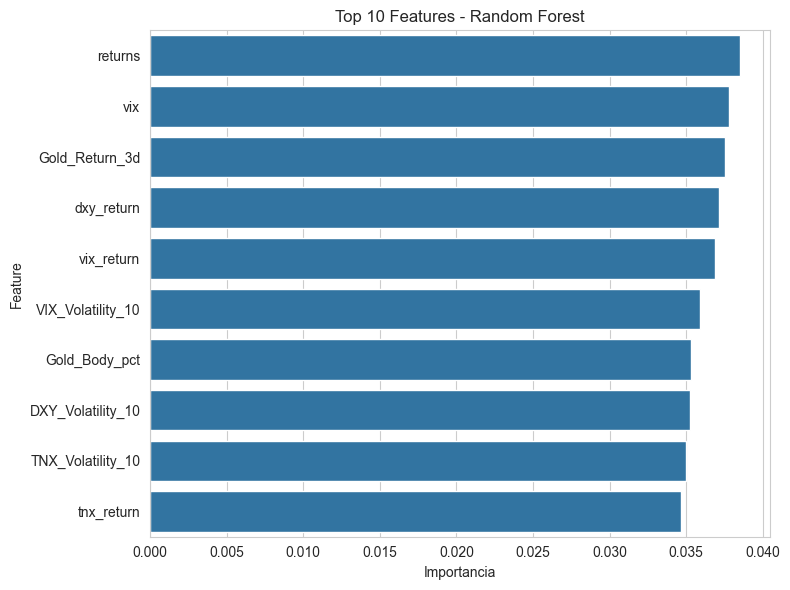

Feature importances:
  returns              0.0385
  vix                  0.0378
  Gold_Return_3d       0.0376
  dxy_return           0.0371
  vix_return           0.0369
  VIX_Volatility_10    0.0359
  Gold_Body_pct        0.0353
  DXY_Volatility_10    0.0352
  TNX_Volatility_10    0.0350
  tnx_return           0.0346


In [17]:
if 'Random Forest' in models:
    rf = models['Random Forest']
    importancias = pd.DataFrame({
        'Feature': feature_cols,
        'Importancia': rf.feature_importances_
    }).sort_values('Importancia', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importancias.head(10), x='Importancia', y='Feature')
    plt.title('Top 10 Features - Random Forest')
    plt.tight_layout()
    plt.show()
    
    print('Feature importances:')
    for _, row in importancias.head(10).iterrows():
        print(f"  {row['Feature']:20s} {row['Importancia']:.4f}")

## 7. Conclusiones

| Aspecto | Resultado |
|---------|-----------|
| **Binaria** | ¿Los modelos superan al baseline? |
| **Multiclase** | ¿Hay señal para 3 categorías balanceadas? |
| **Backtesting** | ¿La estrategia gana a buy & hold? |
| **Overfitting** | ¿Train vs test consistentes? |
| **Features clave** | ¿Qué variables pesan más? |

### Mejoras incorporadas en esta versión

- ✅ Función `add_features()` refactorizada para facilitar experimentación
- ✅ Features OHLC: Body_pct, Range (aprovechan Open/High/Low)
- ✅ Retornos multidis: Gold_Return_3d, Gold_Return_7d
- ✅ MACD_Histogram como señal de cruce
- ✅ MAs y volatilidades para DXY, VIX, TNX (5 y 20 periodos)
- ✅ Distribución de clases validada (value_counts con porcentajes)
- ✅ Umbrales multiclase por cuantiles (33/66) para balancear clases
- ✅ Exploración de umbrales alternativa mostrada en notebook
- ✅ Sin data leakage: scaler ajustado solo en train, split temporal

### Mejoras futuras

1. Añadir CPI y Fed Funds Rate desde FRED
2. Horizonte semanal (más señal, menos ruido)
3. GridSearchCV para ajustar hiperparámetros
4. Estrategia con umbral de confianza (>70% para operar)
5. Walk-forward validation en lugar de split único